In this notebook other datasets are analysed and checked for their possible use in the project.

In [121]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import osmnx as ox
import geopandas as gpd
import openmeteo_requests

import requests_cache
from retry_requests import retry


In [122]:
taxi_data = pl.read_parquet(f'../data/01/01_cleaned_data.parquet')

print(f'Taxi data shape: {taxi_data.shape[0]} rows, {taxi_data.shape[1]} columns')
display(taxi_data.head(2))

Taxi data shape: 109085 rows, 32 columns


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]"
"""c9dbee7a1c639c9d4a1f9954788941…","""515dbaaba624daeb95c3dfefb93bfc…",2024-10-03 23:15:00 CDT,2024-10-03 23:45:00 CDT,30m,13.7,null,null,76,77,35.0,0.0,0.0,7.0,42.0,"""credit card""","""taxi affiliation services""",41.980264,-87.913625,41.986712,-87.663416,27.4,23,4,10,2024-10-03,false,2024-10-03 23:00:00 CDT,2024-10-03 23:00:00 CDT,2024-10-03 20:00:00 CDT,2024-10-03 00:00:00 CDT,2024-09-30 00:00:00 CDT
"""32377b6497b92e4579fbf38af8cf88…","""17aa877caef408e722756baa6747c2…",2024-10-02 11:30:00 CDT,2024-10-02 11:41:30 CDT,11m 30s,1.61,17031081401,17031080202,8,8,9.0,0.0,0.0,0.0,9.0,"""cash""","""chicago independents""",41.895033,-87.619711,41.905858,-87.630865,8.4,11,3,10,2024-10-02,false,2024-10-02 11:30:00 CDT,2024-10-02 11:00:00 CDT,2024-10-02 08:00:00 CDT,2024-10-02 00:00:00 CDT,2024-09-30 00:00:00 CDT


In [123]:
taxi_data.dtypes

[String,
 String,
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Duration(time_unit='ms'),
 Float64,
 Int64,
 Int64,
 Int64,
 Int64,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 String,
 String,
 Float64,
 Float64,
 Float64,
 Float64,
 Float64,
 Int8,
 Int8,
 Int8,
 Date,
 Boolean,
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago'),
 Datetime(time_unit='ms', time_zone='America/Chicago')]

# Holidays
There are different type of holidays in the US, which affect different workgroups. 
- City Holidays: Local services of the city
- State Holidays: State government
- Bank Holidays: Money and Mail
- Corporate Holidays: Private sector

As different groups take different taxi rides, it is relevant to differentiate between the holiday type. Further it is necessary to divide between the work days. Through mobile working and new trends the trip behavior is most likely influenced, e.g. more people work from home in the beginning and ending of the week, also the behavior differs saturdays and sundays.

As the python native holiday package does not support all of them, we decided to use a different source for the holiday data including the day of the week: [Source: https://www.workingdays.us/mobile_home.php](https://www.workingdays.us/mobile_home.php)

## Preprocessing of holiday data
Dropping irrelevant columns, incomplete records and then casting boolean to be an integer.

In [124]:
## Preprocessing of holiday data
holiday_data = pl.read_excel("../data/00/chicago_holidays.xlsx", sheet_name="Calendar")

# Cleanup
holiday_data = holiday_data.drop(['HolidayName', 'HolidaySources', 'BankHolidayName', 
                           'CorporateHolidayName', 'CityHolidayName', 'StateHolidayName', 
                           'DayType'])

# Missing values
print(f"Length before dropping nulls: {len(holiday_data)}")
holiday_data = holiday_data.drop_nulls()
print(f"Length after dropping nulls: {len(holiday_data)}")

# Casting
holiday_data = holiday_data.with_columns(
    pl.col("Date").str.to_date(format="%d.%m.%Y"),
    (pl.col(["BankHoliday", "CorporateHoliday", "CityHoliday", "StateHoliday"])
     .str.to_lowercase() == "true")
     .cast(pl.Int8)
)

#Dummy encoding
holiday_data = holiday_data.to_dummies(columns=["DayOfWeek"], drop_first=True)

# Saving for later use. Use parquet to save datatypes
holiday_data.write_parquet("../data/02/02_holiday_data_cleaned.parquet")

holiday_data.head(3)

Length before dropping nulls: 852
Length after dropping nulls: 852


Date,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday
date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8
2024-01-01,0,0,0,0,0,0,1,1,1,1
2024-01-02,0,0,0,0,1,0,0,0,0,0
2024-01-03,0,0,0,0,0,1,0,0,0,0


## Merging holiday data into taxi data
Holiday/weekday data are merged into the taxi data based on the day when the trip starts. There is also the possibility in which the trip ends on a different day but as seen below this is very unlikely. To reduce training time and prevent additional resource consumption we decided to merge only on the start day.

In [125]:
# Check taxi data on how many records begin and end on different days
taxi_data = taxi_data.with_columns(
    pl.when(pl.col("trip_start").dt.date() != pl.col("trip_end").dt.date())
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias("different_days"),
)

# value counts different_days
print(f'Number of records with different pickup and drop-off days:\n{taxi_data["different_days"].value_counts()}')

# Percentage of value counts
different_days_percentage = taxi_data["different_days"].value_counts(normalize=True)
print(f'Percentage of records with different pickup and drop-off days:\n{different_days_percentage}')

taxi_data = taxi_data.drop("different_days")

Number of records with different pickup and drop-off days:
shape: (2, 2)
┌────────────────┬────────┐
│ different_days ┆ count  │
│ ---            ┆ ---    │
│ i32            ┆ u32    │
╞════════════════╪════════╡
│ 0              ┆ 108742 │
│ 1              ┆ 343    │
└────────────────┴────────┘
Percentage of records with different pickup and drop-off days:
shape: (2, 2)
┌────────────────┬────────────┐
│ different_days ┆ proportion │
│ ---            ┆ ---        │
│ i32            ┆ f64        │
╞════════════════╪════════════╡
│ 1              ┆ 0.003144   │
│ 0              ┆ 0.996856   │
└────────────────┴────────────┘


In [126]:
taxi_data.head(3)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]"
"""c9dbee7a1c639c9d4a1f9954788941…","""515dbaaba624daeb95c3dfefb93bfc…",2024-10-03 23:15:00 CDT,2024-10-03 23:45:00 CDT,30m,13.7,null,null,76,77,35.0,0.0,0.0,7.0,42.0,"""credit card""","""taxi affiliation services""",41.980264,-87.913625,41.986712,-87.663416,27.4,23,4,10,2024-10-03,false,2024-10-03 23:00:00 CDT,2024-10-03 23:00:00 CDT,2024-10-03 20:00:00 CDT,2024-10-03 00:00:00 CDT,2024-09-30 00:00:00 CDT
"""32377b6497b92e4579fbf38af8cf88…","""17aa877caef408e722756baa6747c2…",2024-10-02 11:30:00 CDT,2024-10-02 11:41:30 CDT,11m 30s,1.61,17031081401,17031080202,8,8,9.0,0.0,0.0,0.0,9.0,"""cash""","""chicago independents""",41.895033,-87.619711,41.905858,-87.630865,8.4,11,3,10,2024-10-02,false,2024-10-02 11:30:00 CDT,2024-10-02 11:00:00 CDT,2024-10-02 08:00:00 CDT,2024-10-02 00:00:00 CDT,2024-09-30 00:00:00 CDT
"""f020ca0232592c4c6e1efc21e018e3…","""678095878a2306fa01b08e520d914b…",2024-10-06 22:00:00 CDT,2024-10-06 22:23:57 CDT,23m 57s,12.36,null,null,56,39,31.75,0.0,0.0,4.0,35.75,"""prcard""","""flash cab""",41.792592,-87.769615,41.808916,-87.596183,30.964509,22,7,10,2024-10-06,true,2024-10-06 22:00:00 CDT,2024-10-06 22:00:00 CDT,2024-10-06 20:00:00 CDT,2024-10-06 00:00:00 CDT,2024-09-30 00:00:00 CDT


In [127]:
# Convert both dates to the same column so they are mergable - type date
taxi_data = taxi_data.with_columns(
    pl.col("trip_start").dt.date().alias("date_day")
)
holiday_data = holiday_data.rename({"Date": "date_day"})


# Merge holiday/weekday data into taxi data
taxi_data = taxi_data.join(
    holiday_data,
    on="date_day",
    how="left",
    suffix="_tStart"
)
# .drop("date_day")

display(taxi_data.head())
del holiday_data

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8
"""c9dbee7a1c639c9d4a1f9954788941…","""515dbaaba624daeb95c3dfefb93bfc…",2024-10-03 23:15:00 CDT,2024-10-03 23:45:00 CDT,30m,13.7,null,null,76,77,35.0,0.0,0.0,7.0,42.0,"""credit card""","""taxi affiliation services""",41.980264,-87.913625,41.986712,-87.663416,27.4,23,4,10,2024-10-03,false,2024-10-03 23:00:00 CDT,2024-10-03 23:00:00 CDT,2024-10-03 20:00:00 CDT,2024-10-03 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-03,0,0,0,1,0,0,0,0,0,0
"""32377b6497b92e4579fbf38af8cf88…","""17aa877caef408e722756baa6747c2…",2024-10-02 11:30:00 CDT,2024-10-02 11:41:30 CDT,11m 30s,1.61,17031081401,17031080202,8,8,9.0,0.0,0.0,0.0,9.0,"""cash""","""chicago independents""",41.895033,-87.619711,41.905858,-87.630865,8.4,11,3,10,2024-10-02,false,2024-10-02 11:30:00 CDT,2024-10-02 11:00:00 CDT,2024-10-02 08:00:00 CDT,2024-10-02 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-02,0,0,0,0,0,1,0,0,0,0
"""f020ca0232592c4c6e1efc21e018e3…","""678095878a2306fa01b08e520d914b…",2024-10-06 22:00:00 CDT,2024-10-06 22:23:57 CDT,23m 57s,12.36,null,null,56,39,31.75,0.0,0.0,4.0,35.75,"""prcard""","""flash cab""",41.792592,-87.769615,41.808916,-87.596183,30.964509,22,7,10,2024-10-06,true,2024-10-06 22:00:00 CDT,2024-10-06 22:00:00 CDT,2024-10-06 20:00:00 CDT,2024-10-06 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-06,0,0,1,0,0,0,0,0,0,0
"""949610b40e60ccd02ea4f32f9eed36…","""c60633c5d2053dd1c2076286b88196…",2024-10-02 22:30:00 CDT,2024-10-02 22:45:38 CDT,15m 38s,12.48,null,null,35,75,31.75,0.0,0.0,0.0,31.75,"""prcard""","""chicago independents""",41.835118,-87.618678,41.68973,-87.669054,47.897655,22,3,10,2024-10-02,false,2024-10-02 22:30:00 CDT,2024-10-02 22:00:00 CDT,2024-10-02 20:00:00 CDT,2024-10-02 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-02,0,0,0,0,0,1,0,0,0,0
"""25c3822daf2877a1833941710c464a…","""a4ea50ac80683d3e296a8f8d1f34a4…",2024-10-05 13:45:00 CDT,2024-10-05 14:32:36 CDT,47m 36s,16.52,null,null,76,null,44.5,0.0,0.0,5.0,50.0,"""credit card""","""city service""",41.980264,-87.913625,null,null,20.823529,13,6,10,2024-10-05,true,2024-10-05 13:30:00 CDT,2024-10-05 13:00:00 CDT,2024-10-05 12:00:00 CDT,2024-10-05 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-05,0,1,0,0,0,0,0,0,0,0


# Events
Events are typical destination for and also from Taxi trips. It is expected that not all people travel by public transport or their own cars to concerts, sports matches and other events. The city of Chicago offers a list of such events including their coordinates: https://data.cityofchicago.org/Events/Special-Events/xgse-8eg7/about_data.

The data offers the ward in which the event is taking place as well as the exact location. Further the start time is given.

In [128]:
event_data = pl.read_csv("../data/00/chicago_events_20260515.csv", null_values=["", "N/A", "NA", "NaN"])
event_data = event_data.drop(['Venue', ])

display(event_data.head(2))

Date,Venue Address,Event Type,Event Details,Start Time,Ward,Location
str,str,str,str,str,str,str
"""11/21/2025""","""50 W. Washington Street""","""Special Event""","""Christkindlmarket - Chicago""","""11:00AM""","""42""","""POINT (-87.6302 41.88325)"""
"""11/22/2025""","""50 W. Washington Street""","""Special Event""","""Christkindlmarket - Chicago""","""11:00AM""","""42""","""POINT (-87.6302 41.88325)"""


In [129]:
display(event_data.null_count())

Date,Venue Address,Event Type,Event Details,Start Time,Ward,Location
u32,u32,u32,u32,u32,u32,u32
0,0,0,1,286,0,16


Over half of the event data have missing values, therefore it is difficult to map the individual event records to matching timeframes. We decided <b>against</b> merging the event data into the texi data because of the high incompleteness of the data. Further the affected number of trips may be low as the time and the location have to match.

# Open Meteo Weather Data
Following data source provides weather data within chicago at an hourly rate instead of the daily rate provided by the sampling. We take into account that the temperature is different within the city but generally it is expected to change throughout the day more or less evenly. Using a hourly sample rate enables to use day and night temperature influences for later models.

Source:
https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&hourly=temperature_2m,rain,snowfall,wind_speed_10m&start_date=2024-01-01&daily=temperature_2m_max,temperature_2m_min&timezone=America%2FChicago

In [130]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 41.85,
	"longitude": -87.65,
	"start_date": "2024-01-01",
	"end_date": "2026-06-14",
	"daily": ["temperature_2m_max", "temperature_2m_min"],
	"hourly": ["temperature_2m", "rain", "snowfall", "wind_speed_10m"],
	"timezone": "America/Chicago",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
hourly_rain = hourly.Variables(1).ValuesAsNumpy()
hourly_snowfall = hourly.Variables(2).ValuesAsNumpy()
hourly_wind_speed_10m = hourly.Variables(3).ValuesAsNumpy()

hourly_data = {
	"date": pd.date_range(
		start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = hourly.Interval()),
		inclusive = "left"
	).tz_convert(response.Timezone().decode())
}

hourly_data["temperature_2m"] = hourly_temperature_2m
hourly_data["rain"] = hourly_rain
hourly_data["snowfall"] = hourly_snowfall
hourly_data["wind_speed_10m"] = hourly_wind_speed_10m

hourly_dataframe = pd.DataFrame(data = hourly_data)
hourly_dataframe.rename(columns = {"temperature_2m": "temperature_c",
                                   "rain": "rain_mm",
                                   "snowfall": "snowfall_mm",
                                   "wind_speed_10m": "wind_speed_kmh"
                                   }, inplace = True)
print("\nHourly data\n")
display(hourly_dataframe.head(2))
print("\nHourly data description\n")
display(hourly_dataframe.describe())

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_max = daily.Variables(0).ValuesAsNumpy()
daily_temperature_2m_min = daily.Variables(1).ValuesAsNumpy()

# Daily buckets are local calendar days. A fixed 86400s step (daily.Interval())
# does not track calendar days across a DST transition (23h/25h days), so we
# anchor on start_date and step by calendar day instead.
daily_data = {
	"date": pd.date_range(start = params["start_date"], periods = len(daily_temperature_2m_max), freq = "D")
}

daily_data["temperature_2m_max"] = daily_temperature_2m_max
daily_data["temperature_2m_min"] = daily_temperature_2m_min

daily_dataframe = pd.DataFrame(data = daily_data)
daily_dataframe.rename(columns = {"temperature_2m_max": "temperature_max_c",
                                  "temperature_2m_min": "temperature_min_c"
                                  }, inplace = True)
print("\nDaily data\n")
display(daily_dataframe.head(2))
print("\nDaily data description\n")
display(daily_dataframe.describe())


Coordinates: 41.8629150390625°N -87.64877319335938°E
Elevation: 179.0 m asl
Timezone: b'America/Chicago'b'GMT-5'
Timezone difference to GMT+0: -18000s

Hourly data



,date,temperature_c,rain_mm,snowfall_mm,wind_speed_kmh
0,2023-12-31 23:00:00-06:00,0.55,0.0,0.07,30.449274
1,2024-01-01 00:00:00-06:00,0.35,0.0,0.07,30.449274



Hourly data description



,temperature_c,rain_mm,snowfall_mm,wind_speed_kmh
count,21504.000000,21504.000000,21504.000000,21504.000000
mean,10.397561,0.097015,0.007539,14.189479
std,11.128804,0.564121,0.069302,6.960883
min,-24.850000,0.000000,0.000000,0.000000
25%,2.087500,0.000000,0.000000,9.109138
50%,10.800000,0.000000,0.000000,13.246826
75%,19.549999,0.000000,0.000000,18.354485
max,36.200001,19.799999,3.290000,45.092064



Daily data



,date,temperature_max_c,temperature_min_c
0,2024-01-01,1.35,-2.6
1,2024-01-02,2.50,-4.6



Daily data description



,date,temperature_max_c,temperature_min_c
count,896,896.000000,896.000000
mean,2025-03-23 12:00:00,14.550837,6.506306
min,2024-01-01 00:00:00,-17.350000,-24.850000
25%,2024-08-11 18:00:00,5.837500,-1.000000
50%,2025-03-23 12:00:00,15.775000,6.825000
75%,2025-11-02 06:00:00,24.062500,15.325000
max,2026-06-14 00:00:00,36.200001,25.900000
std,NaN,11.344478,10.447009


## Merge daily into hourly data set

In [131]:
# Convert to polars and merge on the day of the hourly data record
hourly_for_merge = pl.from_pandas(hourly_dataframe).with_columns(
    pl.col("date").dt.strftime("%Y-%m-%d").alias("date_day")
)

daily_for_merge = pl.from_pandas(daily_dataframe).with_columns(
    pl.col("date").dt.strftime("%Y-%m-%d").alias("date_day")
)

weather_data = hourly_for_merge.join(
    daily_for_merge.drop("date"),
    on="date_day",
    how="left"
).drop("date_day")

del hourly_for_merge
del daily_for_merge

display(weather_data.head(1))

date,temperature_c,rain_mm,snowfall_mm,wind_speed_kmh,temperature_max_c,temperature_min_c
"datetime[ms, America/Chicago]",f32,f32,f32,f32,f32,f32
2023-12-31 23:00:00 CST,0.55,0.0,0.07,30.449274,null,null


## Plots
Below are the weather data plotted in various formats. In the first plot one can see the min and max temperature of each day over the time from 2024-01-01 until now.

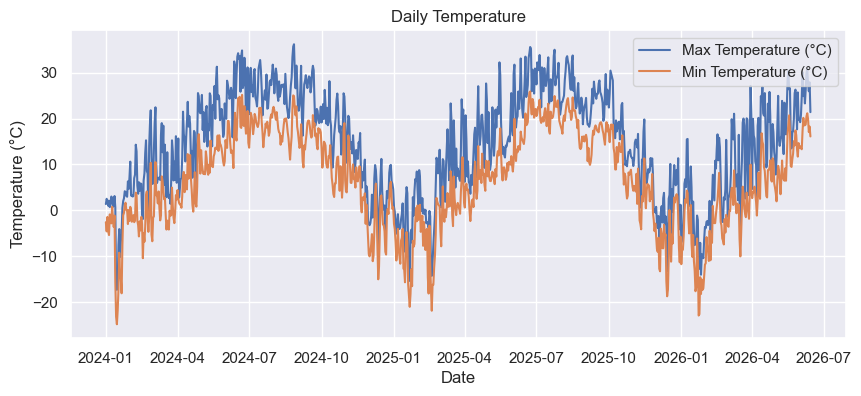

In [132]:
# plot daily weather data
plt.figure(figsize = (10,4))
plt.plot(daily_dataframe["date"], daily_dataframe["temperature_max_c"], label = "Max Temperature (°C)")
plt.plot(daily_dataframe["date"], daily_dataframe["temperature_min_c"], label = "Min Temperature (°C)")
plt.title("Daily Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

### Weather data over time
Below you can see the weather data over time. You can especially see the change between summer and winter.

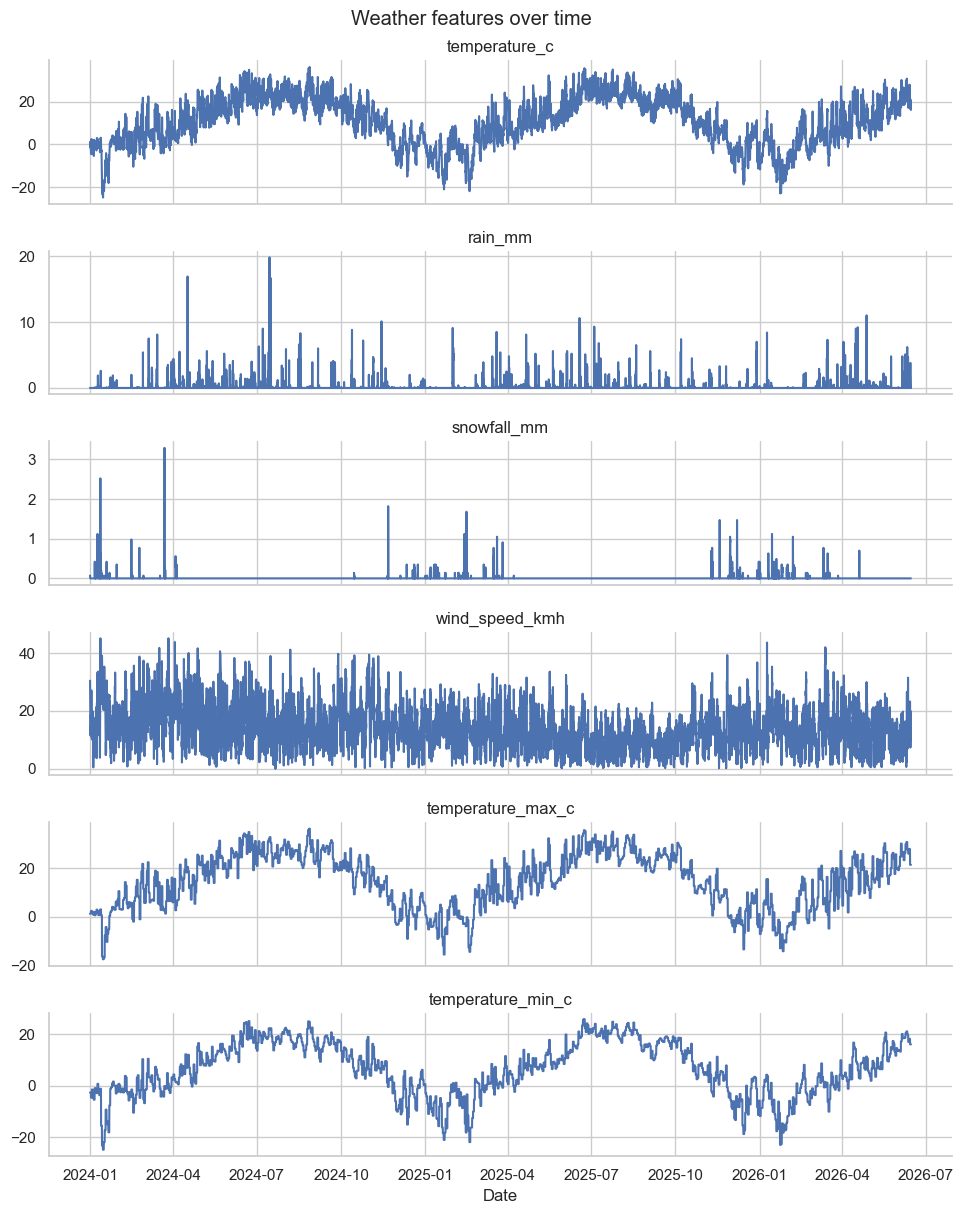

In [133]:
# all weather features over time in a single figure
feature_cols = [c for c in weather_data.columns if c != "date"]

# reshape to long format so seaborn can facet by feature
weather_long = weather_data.unpivot(
    index="date",
    on=feature_cols,
    variable_name="feature",
    value_name="value",
).to_pandas()

# one row per feature, shared x-axis (date) but independent y-scales
sns.set_theme(style="whitegrid")
g = sns.relplot(
    data=weather_long,
    x="date",
    y="value",
    row="feature",
    kind="line",
    height=2,
    aspect=5,
    facet_kws={"sharey": False},
)
g.set_titles(row_template="{row_name}")
g.set_axis_labels("Date", "")
g.figure.suptitle("Weather features over time", y=1.01)
plt.show()

## Missing values
Below you can see that after the merger 69 records have missing daily values due to the merger. You can see that three days are missing. In case the two daily weather columns/features are irrelevant during the prediction, the two columns can be dropped, otherwise the incomplete 69 records are dropped for now.

In [134]:
print('Number of missing values per column:')
display(weather_data.null_count())
print('\n')

# Show the date of when the records are incomplete
incomplete_dates = weather_data.filter(
    pl.col("temperature_c").is_null() | pl.col("temperature_max_c").is_null() | pl.col("temperature_min_c").is_null()
).select(pl.col("date").dt.date().alias("date_day")).unique()
print('Dates of which the daily data is missing:')
display(incomplete_dates)

Number of missing values per column:


date,temperature_c,rain_mm,snowfall_mm,wind_speed_kmh,temperature_max_c,temperature_min_c
u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,1,1




Dates of which the daily data is missing:


date_day
date
2023-12-31


In [135]:
incomplete_weather_records = weather_data.filter(
    pl.col("temperature_max_c").is_null() & pl.col("temperature_min_c").is_null()
)
print("Number of records missing both, min and max temperature of the day:", incomplete_weather_records.height)

Number of records missing both, min and max temperature of the day: 1


In [136]:
print('Number of weather records before dropping nulls:', weather_data.height)
weather_data = weather_data.drop_nulls()
print('Number of weather records after dropping nulls:', weather_data.height)

Number of weather records before dropping nulls: 21504
Number of weather records after dropping nulls: 21503


## Discretization
It is necessary to discretize variables the prediction should later something like "what demand can we expect on a rainy Sunday from 10 – 11 am	around the outskirts of	the	city". The weather columns are still continious and very broad by their distribution (see below). Therefore we need to define limits and discretize the values into columns like rainy, snowy, windy and other.

To do this, we plot the distribution first and then decide the limits for rainy, snowy and other.

> [NOTE] The distribution plots for rain and snow exclude zero values as these are the majority. Without the zero values the rest of the distribution becomes better visible.

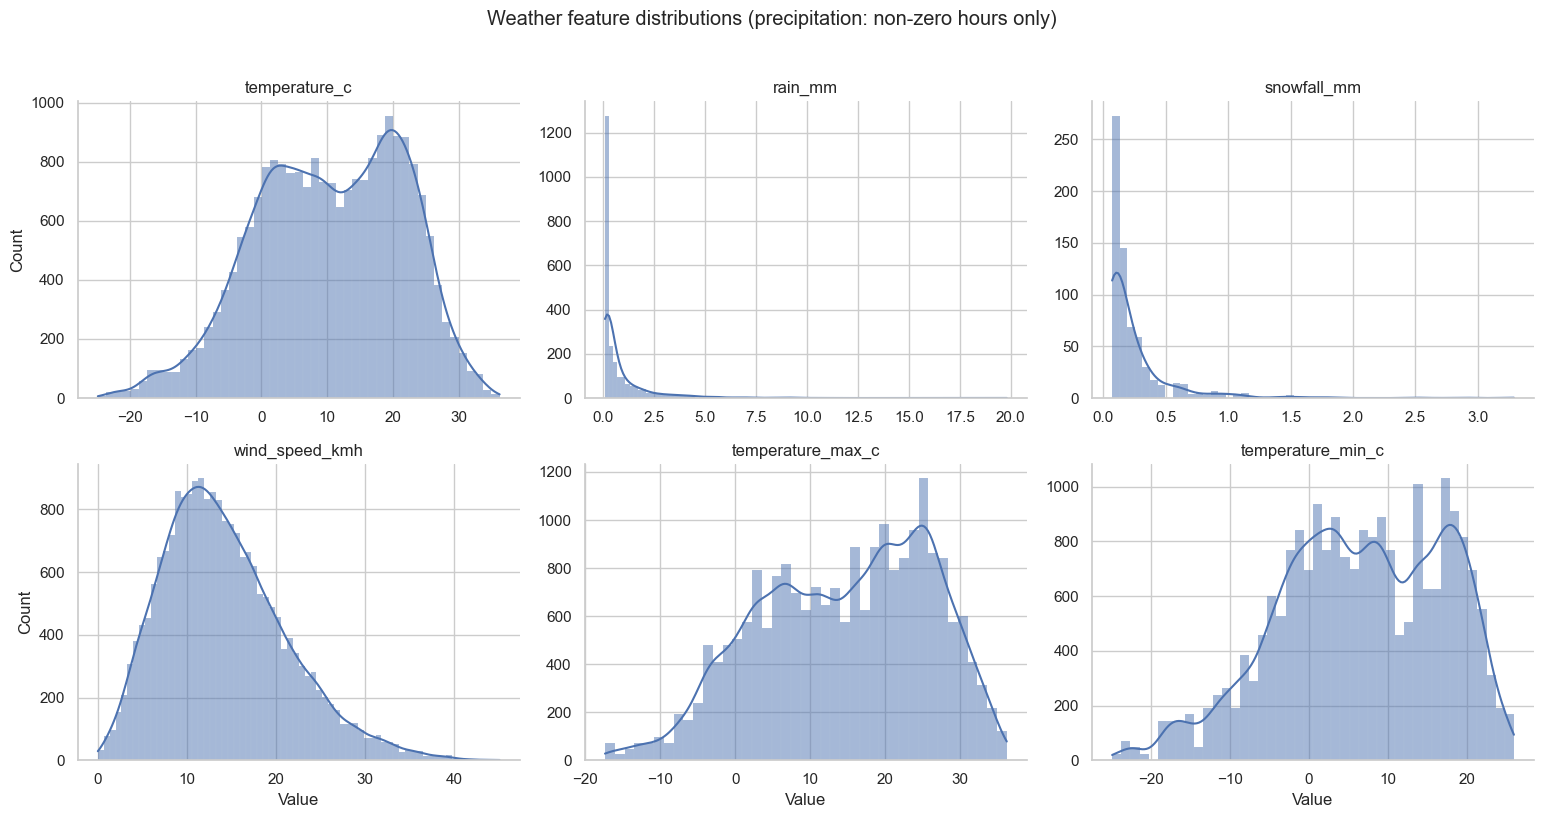

In [137]:
# precip_cols = ["rain", "snow"]
drop_zero_precip = weather_long["feature"].isin(["rain_mm", "snowfall_mm"]) & (weather_long["value"] == 0)
dist_data = weather_long[~drop_zero_precip]

g = sns.displot(
    data=dist_data,
    x="value",
    col="feature",
    col_wrap=3,
    kind="hist",
    kde=True,
    common_bins=False,
    facet_kws={"sharex": False, "sharey": False},
    height=4,
    aspect=1.3,
)
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Value", "Count")
g.figure.suptitle("Weather feature distributions (precipitation: non-zero hours only)", y=1.02)
g.tight_layout()
plt.show()

Based on the distribution we discretize the `rain_mm` into based on (Source)[https://en.wikipedia.org/wiki/Precipitation_types#Intensity]:
- `rain`: 0.2 mm <=`rain_mm` =< 4.0 mm
- `strong_rain`: `rain_mm` > 4.0 mm

`snowfall_mm` is much less distributed than `rain_mm`, therefore it is decided that everythin about 0.2 mm categorized as snow:
- `snow`: `snowfall_mm` >= 0.2 mm

`wind_speed_kmh` is classified based on (Source)[https://en.wikipedia.org/wiki/Beaufort_scale] into:
- `wind`:  8 kmh <= `wind_speed_kmh` <=25 kmh
- `strong_wind`: `wind_speed_kmh` > 25 kmh

> <b>NOTE</b> We adjusted the wind strong wind and heavy rain a bit, so that more records were classified in these categories, as the original thresholds of 28 kmh and 7.6 were to low and only a few hundred hours of the 20,000 plus hours were classified as these

Temperatures are kept as they are.

In [138]:
# Discretize the continuous weather columns into binary indicator columns (1/0) based on the thresholds above.
weather_data = weather_data.with_columns(
    ((pl.col("rain_mm") >= 0.2) & (pl.col("rain_mm") <= 4)).cast(pl.Int8).alias("rain"),
    (pl.col("rain_mm") > 4).cast(pl.Int8).alias("strong_rain"),
    (pl.col("snowfall_mm") >= 0.2).cast(pl.Int8).alias("snow"),
    ((pl.col("wind_speed_kmh") >= 8) & (pl.col("wind_speed_kmh") <= 25)).cast(pl.Int8).alias("wind"),
    (pl.col("wind_speed_kmh") > 25).cast(pl.Int8).alias("strong_wind"),
).drop("rain_mm", "snowfall_mm", "wind_speed_kmh")

# save for later use
weather_data.write_parquet("../data/02/02_weather_data_cleaned.parquet")

display(weather_data.head(2))

date,temperature_c,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind
"datetime[ms, America/Chicago]",f32,f32,f32,i8,i8,i8,i8,i8
2024-01-01 00:00:00 CST,0.35,1.35,-2.6,0,0,0,0,1
2024-01-01 01:00:00 CST,0.5,1.35,-2.6,0,0,0,0,1


To see how many records of the weather data are affected we can take a look at the following plot. Especially wind is present in most of the records, while the others are less often.

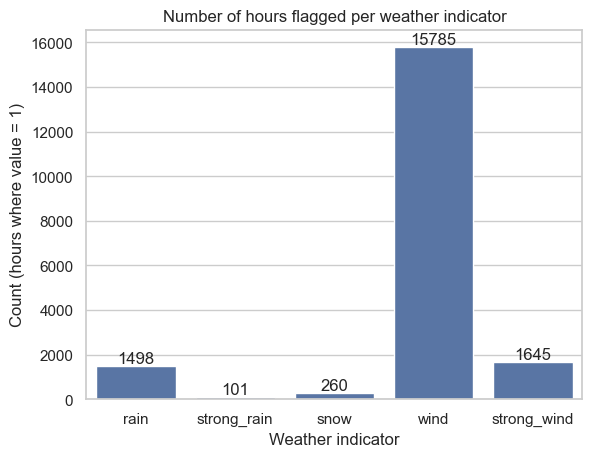

In [139]:
#| label: fig-numbers-flagged-weather-indicators
#| fig-cap: "Number of hours flagged per weather indicator. The counts are based on the binary indicator columns created from the continuous weather variables."
indicator_cols = ["rain", "strong_rain", "snow", "wind", "strong_wind"]
counts = (
    weather_data.select(pl.col(indicator_cols).sum())
    .to_pandas()
    .T.rename(columns={0: "count"})
)

ax = sns.barplot(x=counts.index, y=counts["count"])
ax.set_title("Number of hours flagged per weather indicator")
ax.set_xlabel("Weather indicator")
ax.set_ylabel("Count (hours where value = 1)")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

## Merge date into taxi-data
Relevant are the two timestamp columns for the merger. Since the weather data is hourly we can truncate both datasets timestamps to an hour and join it based on this truncated timestamp.

In [140]:
taxi_data = taxi_data.with_columns(
    pl.col("trip_start").dt.truncate("1h").alias("weather_hour")
).sort("weather_hour")
weather_data = (
    weather_data.with_columns(
        pl.col("date").dt.truncate("1h").alias("weather_hour")
    )
    .sort("weather_hour")
)
merged_data = taxi_data.join(
    weather_data,
    on="weather_hour",
    how="left",
)

del weather_data

# merged_data = merged_data.drop('date_right')
display(merged_data.head(1))

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,weather_hour,date_right,temperature_c,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f32,f32,f32,i8,i8,i8,i8,i8
"""a8c91deed78eb0610e261e5c61f39c…","""16a529a73f019759aa8f1b563ab851…",2024-10-01 00:00:00 CDT,2024-10-01 00:06:00 CDT,6m,1.3,null,null,8,8,6.75,0.0,0.0,1.0,7.75,"""cash""","""taxi affiliation services""",41.899602,-87.633308,41.899602,-87.633308,13.0,0,2,10,2024-10-01,false,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,17.9,19.15,13.55,0,0,0,1,0


Below you can see the time differences of the trip_start to the timestamp of the weather (renamed by the join to date_right). The results are very good and the maximum is below an hour.

In [141]:
merged_data = merged_data.with_columns(
    (pl.col("trip_start") - pl.col("date_right")).abs().alias("delta_time")
).drop("date_right")

delta_stats = merged_data.select(
    pl.col("delta_time").min().alias("min"),
    pl.col("delta_time").max().alias("max"),
    pl.col("delta_time").mean().alias("mean"),
).row(0)

print(f"Minimum time difference: {delta_stats[0]}")
print(f"Maximum time difference: {delta_stats[1]}")
print(f"Average time difference: {delta_stats[2]}")


Minimum time difference: 0:00:00
Maximum time difference: 0:45:00
Average time difference: 0:22:22.496000


There are still missing values by the original taxi data but the three days which miss the daily weather data affect around 31 thousand records.

In [142]:
# calculate number of nulls in merged data
print('Number of missing values per column in merged data:')
display(merged_data.null_count())

missing_weather_dates = merged_data.filter(
    pl.col("temperature_c").is_null() | pl.col("temperature_max_c").is_null() | pl.col("temperature_min_c").is_null()
).select(pl.col("weather_hour").dt.date().alias("date_day")).unique()
print("Days where weather data is missing:")
display(missing_weather_dates)

incomplete_weather_records = merged_data.filter(
    pl.col("temperature_max_c").is_null() & pl.col("temperature_min_c").is_null()
)
print("Daily missing weather data causes on the three days the following number of records to be incomplete:", incomplete_weather_records.height)

Number of missing values per column in merged data:


trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,weather_hour,temperature_c,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind,delta_time
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,60847,62750,0,9311,0,0,0,0,0,0,0,0,0,8498,8498,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Days where weather data is missing:


date_day
date


Daily missing weather data causes on the three days the following number of records to be incomplete: 0


><b>[NOTE]</b> Keep in mind, that we have not dropped the missing values where the pickup census tract is not given and also not the missing dropoff values. Therefore the nulls are expected.

Lastly, belows plot shows the distribution the average delta time over the whole timeframe of the taxi dataset.

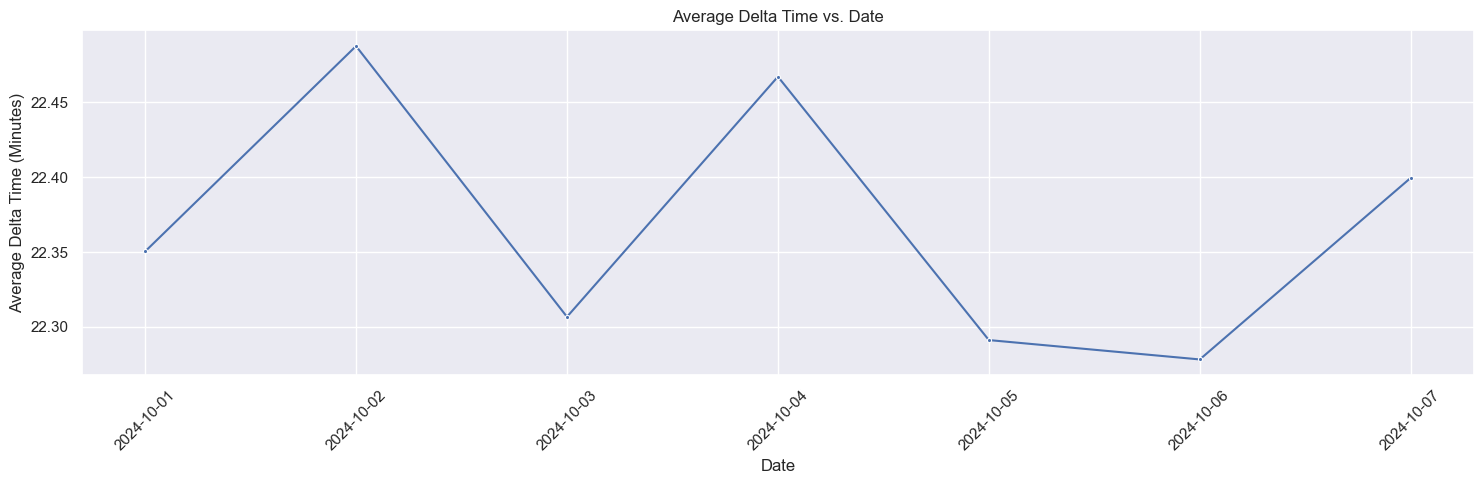

In [143]:
plot_data = (
    merged_data.with_columns(
        pl.col("delta_time").dt.total_minutes().alias("delta_time_minutes"), # convert to minutes
        pl.col("trip_start").dt.date().alias("date_day"),
    )
    .group_by("date_day")
    .agg(pl.col("delta_time_minutes").mean().alias("avg_delta_time_minutes"))
    .sort("date_day")
    .to_pandas()
)

sns.set_theme(style="darkgrid")

plt.figure(figsize=(15, 5))

# Seaborn can natively take Polars series
sns.lineplot(
    x=plot_data["date_day"], 
    y=plot_data["avg_delta_time_minutes"],
    marker="o",
    markersize=3
)

plt.xlabel("Date")
plt.ylabel("Average Delta Time (Minutes)")
plt.title("Average Delta Time vs. Date")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Plots Trip Weather Data
After merging the hourly weather indicators into the trip records, each trip now has additional data about the weather. Belows plots hsow how many trips per day were affected by each weather column.

In [144]:
indicator_cols = ["rain", "strong_rain", "snow", "wind", "strong_wind"]

trips_per_weather = (
    merged_data.with_columns(
        pl.col("trip_start").dt.date().alias("date_day")
    )
    .group_by("date_day")
    .agg([pl.col(c).sum().alias(c) for c in indicator_cols]) # aggregate sum of each weather column for the date_day
    .sort("date_day")
    .to_pandas()
)

sns.set_theme(style="darkgrid")

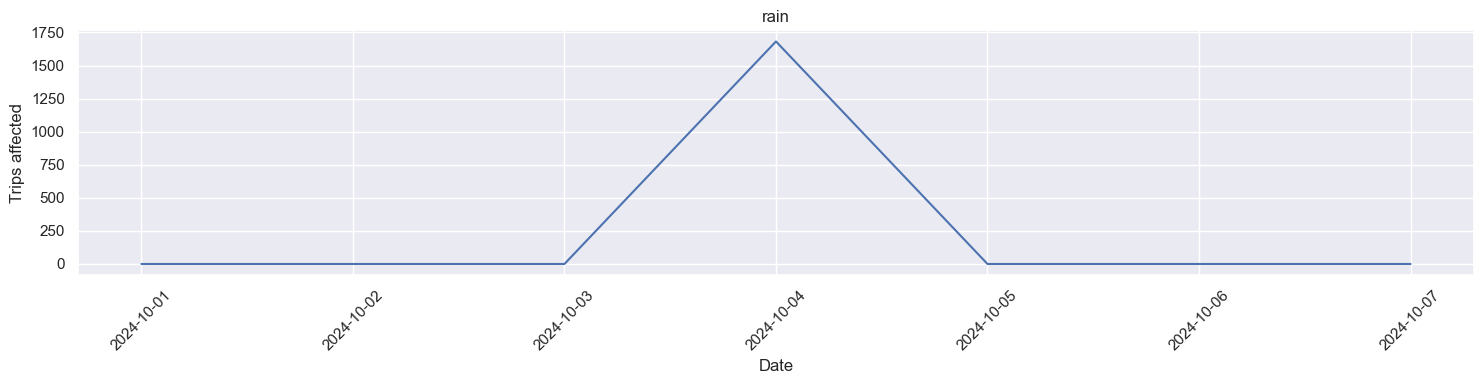

In [145]:
#| label: fig-trips-rain
#| fig-cap: "Number of taxi trips affected by rain per day over time."
plt.figure(figsize=(15, 4))
ax = sns.lineplot(x=trips_per_weather["date_day"], y=trips_per_weather["rain"])
ax.set_title("rain")
ax.set_xlabel("Date")
ax.set_ylabel("Trips affected")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

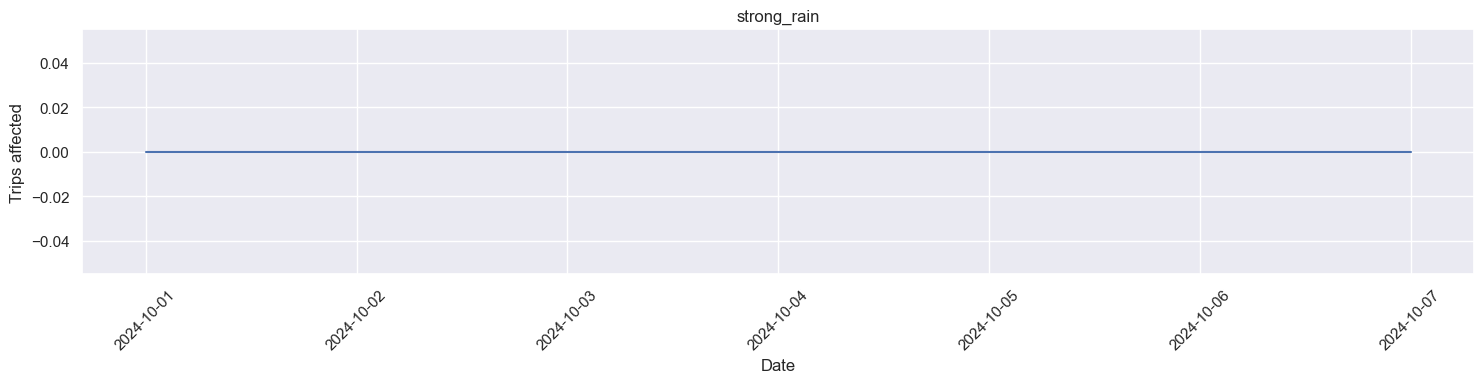

In [146]:
#| label: fig-trips-strong-rain
#| fig-cap: "Number of taxi trips affected by strong rain per day over time."
plt.figure(figsize=(15, 4))
ax = sns.lineplot(x=trips_per_weather["date_day"], y=trips_per_weather["strong_rain"])
ax.set_title("strong_rain")
ax.set_xlabel("Date")
ax.set_ylabel("Trips affected")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

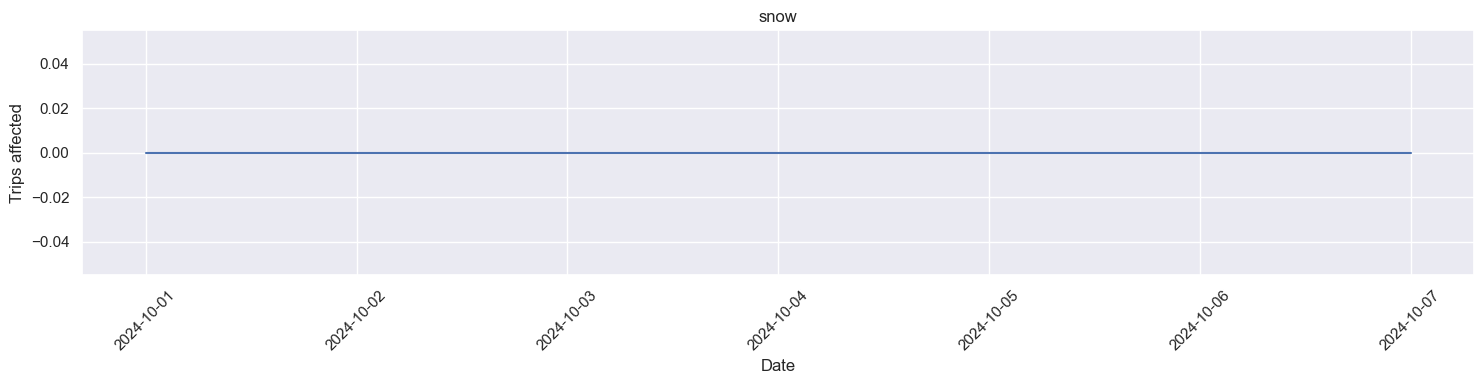

In [147]:
#| label: fig-trips-snow
#| fig-cap: "Number of taxi trips affected by snow per day over time."
plt.figure(figsize=(15, 4))
ax = sns.lineplot(x=trips_per_weather["date_day"], y=trips_per_weather["snow"])
ax.set_title("snow")
ax.set_xlabel("Date")
ax.set_ylabel("Trips affected")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

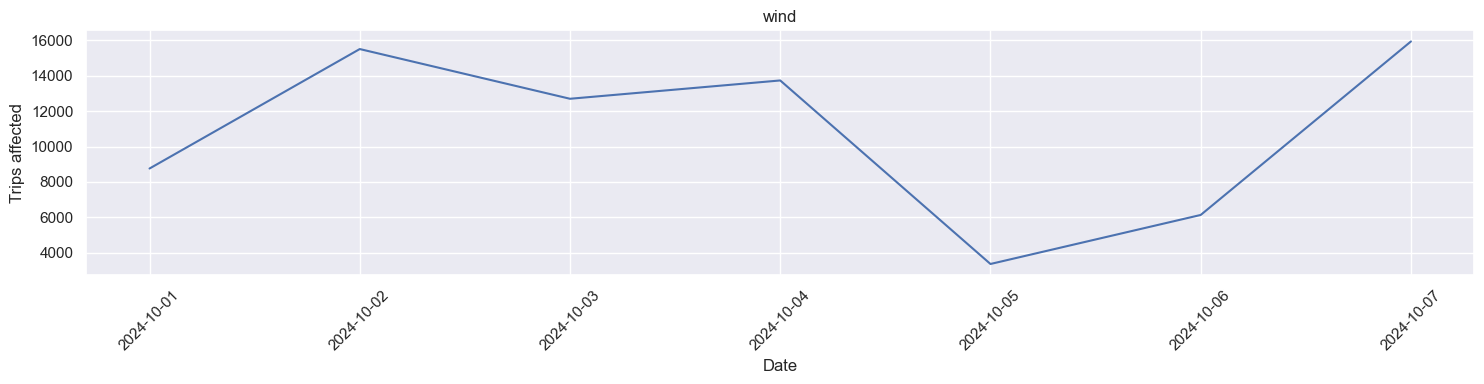

In [148]:
#| label: fig-trips-wind
#| fig-cap: "Number of taxi trips affected by wind per day over time."
plt.figure(figsize=(15, 4))
ax = sns.lineplot(x=trips_per_weather["date_day"], y=trips_per_weather["wind"])
ax.set_title("wind")
ax.set_xlabel("Date")
ax.set_ylabel("Trips affected")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

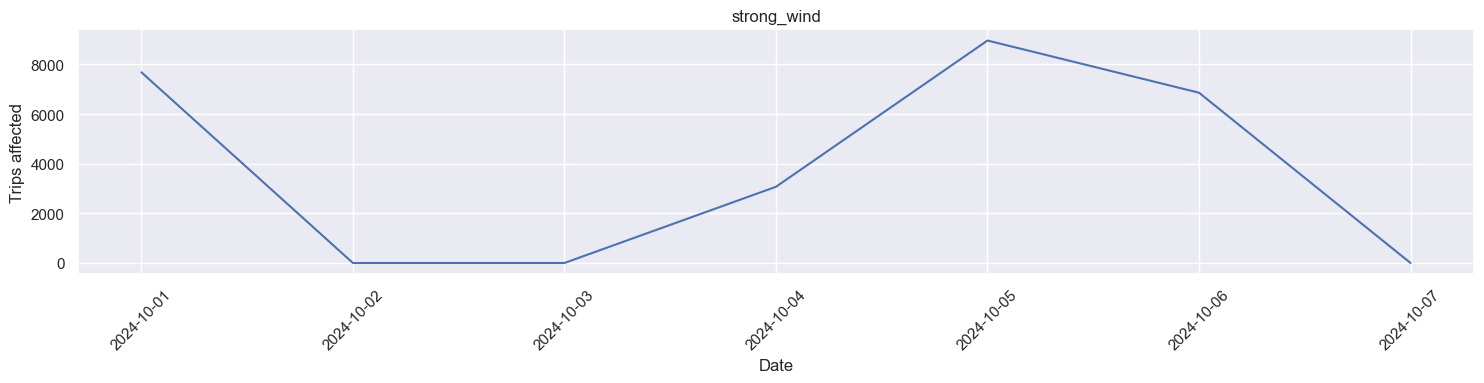

In [149]:
#| label: fig-trips-strong-wind
#| fig-cap: "Number of taxi trips affected by strong wind per day over time."
plt.figure(figsize=(15, 4))
ax = sns.lineplot(x=trips_per_weather["date_day"], y=trips_per_weather["strong_wind"])
ax.set_title("strong_wind")
ax.set_xlabel("Date")
ax.set_ylabel("Trips affected")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Points of Interest
Taxi demand depends on people traveling from and to specific locations. People might travel home from a restaurant, go to a concert hall, go home from shopping, etc. These points are also called Point-Of-Interest or short POI. They are used as an additional source to explain the reason of trips. Census tracts with many POI are expected to be more busy. 

We use POI from [OpenStreetMap](https://www.openstreetmap.org) via the osmnx package.<br>
Because different kinds of place attract different trips, we first sort every POI into one of eight categories:
| category | example |
|---|---|
| `healthcare` | pharmacy, hospital, clinic, doctors, dentist, nursing home, chemist |
| `education` | school, university, college, kindergarten |
| `public_services` | library, townhall, police, fire station, post office, government office |
| `tourism` | hotel, museum, attraction |
| `nature` | park, garden, nature reserve, forest, grass, protected areas |
| `amenity` | bar, pub, restaurant, cafe, nightclub, fast food |
| `leisure` | fitness centre, sports centre, stadium, pitch |
| `shops` | retail shops |

We hope that by differentiating between the different POIs that the model learns interest like people traveling to night clubs in the evening or going to tourist attractions only during the opening hours. We further aggregate the categories into two additional data batches, one on community level and the other on census tract level for the spatial temporal analysis.

The aggregation uses the two spatial granularities already present in `merged_data`:
1. Census tracts (`pickup_census_tract` / `dropoff_census_tract`)
2. Community areas (`pickup_community_area` / `dropoff_community_area`)

The resulting per-category counts are merged back onto both the pickup and the dropoff location of every trip.

Starting with queriying the data from OpenStreetMap by selecting the specific queries and value restrictions.

Summary:
1. First query the raw POIs with OpenStreetMap tag key. 
2. FIlter tag keys more specific for defined categories
3. Merge POI into census tract and community area for descriptive analytics.
4. Store data seperately to further usage


> <b>[NOTE]</b> These POIs are from the today and the actual value in the past might be different. Example: Shops/Restaurants might be opened recently and were not in the area back in the beginning of 2024.

In [150]:
TAG_QUERIES = {
    "amenity": True,
    "shop": True,
    "leisure": True,
    "tourism": True,
    "healthcare": True,
    "natural": ["beach", "wood", "water", "wetland", "tree_row", "scrub", "grassland"],
    "landuse": ["forest", "recreation_ground", "grass", "meadow", "village_green"],
    "office": ["government"],
    "boundary": ["national_park", "protected_area"],
}
POI_TAG_COLS = list(TAG_QUERIES.keys())

parts = []
for key, value in TAG_QUERIES.items():
    layer = ox.features_from_place("Chicago, Illinois, USA", tags={key: value})
    print(f"  {key}: {len(layer)} features")
    parts.append(layer)


for layer in parts:
    for col in POI_TAG_COLS:
        if col not in layer.columns:
            layer[col] = np.nan
poi_raw = pd.concat([layer[POI_TAG_COLS + ["geometry"]] for layer in parts])
poi_raw = poi_raw[~poi_raw.index.duplicated(keep="first")].copy()

print(f"\nTotal unique points of interest: {len(poi_raw)}")

  amenity: 36973 features
  shop: 5744 features
  leisure: 11024 features
  tourism: 1545 features
  healthcare: 824 features
  natural: 2209 features
  landuse: 7202 features
  office: 137 features
  boundary: 21 features

Total unique points of interest: 64766


Further these are categorized into the proposed eight categories for further usage.

In [151]:
# Define tags that belong to each category
FOOD_DRINK = {"bar", "pub", "restaurant", "cafe", "nightclub", "fast_food", 
              "food_court", "ice_cream", "biergarten"}
HEALTH_AMENITY = {"pharmacy", "hospital", "clinic", "doctors", "dentist", 
                  "nursing_home", "social_facility", "veterinary", "baby_hatch"}
HEALTH_SHOP = {"chemist", "medical_supply", "optician", "hearing_aids"}
EDUCATION = {"school", "university", "college", "kindergarten", "language_school", 
             "music_school", "driving_school", "prep_school", "childcare"}
PUBLIC_SERVICES = {"library", "townhall", "police", "fire_station", "post_office", 
                   "courthouse", "community_centre", "social_centre", "public_building", 
                   "prison", "ranger_station"}
NATURE_LEISURE = {"park", "nature_reserve", "garden", "dog_park"}
NATURE_LANDUSE = {"forest", "recreation_ground", "grass", "meadow", "village_green"}
PROTECTED = {"national_park", "protected_area"}

# set up conditions for categorization
conditions = [
    poi_raw["healthcare"].notna() | poi_raw["amenity"].isin(HEALTH_AMENITY) | poi_raw["shop"].isin(HEALTH_SHOP),
    poi_raw["amenity"].isin(EDUCATION),
    poi_raw["amenity"].isin(PUBLIC_SERVICES) | (poi_raw["office"] == "government"),
    poi_raw["tourism"].notna(),
    poi_raw["leisure"].isin(NATURE_LEISURE) | poi_raw["natural"].notna() | poi_raw["landuse"].isin(NATURE_LANDUSE) | poi_raw["boundary"].isin(PROTECTED),
    poi_raw["amenity"].isin(FOOD_DRINK),
    poi_raw["leisure"].notna(),
    poi_raw["shop"].notna()
]

# possible categories in the order as conditions
choices = [
    "healthcare", "education", "public_services", "tourism", 
    "nature", "amenity", "leisure", "shops"
]

# select the one which matches the condition
poi_raw["category"] = np.select(conditions, choices, default=None)

# Drop uncategorized, keep only relevant columns and get geometry points
poi_points = poi_raw.dropna(subset=["category"]).copy()
poi_points["geometry"] = poi_points.geometry.representative_point()
poi_points = poi_points[["category", "geometry"]].reset_index(drop=True)

# Statistics
print(f"Categorized points of interest: {len(poi_points)} of {len(poi_raw)}")
print("\nPOI per category:")
display(poi_points["category"].value_counts())

poi_categorized = poi_points.copy()
poi_categorized["lon"], poi_categorized["lat"] = poi_categorized.geometry.x, poi_categorized.geometry.y
poi_categorized = poi_categorized[["category", "lon", "lat"]]
poi_categorized.to_csv("../data/02/02_poi_categorized.csv", index=False)

print(f"Saved ../data/02/02_poi_categorized.csv  ({len(poi_categorized)} POIs)")
display(poi_categorized.head(3))

Categorized points of interest: 36479 of 64766

POI per category:


category
nature             14623
amenity             5808
leisure             5764
shops               5493
tourism             1545
healthcare          1304
education           1286
public_services      656
Name: count, dtype: int64

Saved ../data/02/02_poi_categorized.csv  (36479 POIs)


,category,lon,lat
0,tourism,-87.622517,41.889145
1,amenity,-87.649212,41.925574
2,public_services,-87.653429,41.925666


## Merging each POI to a census tract and community area
The individual POIs with their respective category are aggregated on a census tract and community area level. Both are aggregated so that we can later easily switch between the two for the demand prediction.We use the boundaries provided by the city of Chicago ([census tracts](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Census_Tracts/4hp8-2i8z/about_data), [community areas](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas/cauq-8yn6/about_data))

In [152]:
census_geo = pl.read_csv("../data/00/Census_Tracts.csv").to_pandas()
tracts = gpd.GeoDataFrame(
    census_geo[["CENSUS_T_1"]].rename(columns={"CENSUS_T_1": "census_tract"}),
    geometry=gpd.GeoSeries.from_wkt(census_geo["the_geom"]),
    crs="EPSG:4326",
)

community_geo = pl.read_csv("../data/00/Community_Areas.csv").to_pandas()
communities = gpd.GeoDataFrame(
    community_geo[["AREA_NUMBE"]].rename(columns={"AREA_NUMBE": "community_area"}),
    geometry=gpd.GeoSeries.from_wkt(community_geo["the_geom"]),
    crs="EPSG:4326",
)


poi_tract = pl.from_pandas(
    gpd.sjoin(poi_points, tracts, how="inner", predicate="within")[["census_tract", "category"]]
)
poi_community = pl.from_pandas(
    gpd.sjoin(poi_points, communities, how="inner", predicate="within")[["community_area", "category"]]
)
print(f"POI located in a census tract: {poi_tract.height} of {len(poi_points)}")
print(f"POI located in a community area: {poi_community.height} of {len(poi_points)}")


CATEGORIES = ["healthcare", "education", "amenity", "leisure",
              "shops", "public_services", "tourism", "nature"]
# Count POI per category for each spatial unit and pivot to one column per category.
def poi_counts_by(frame, group_col):
    wide = (
        frame.group_by([group_col, "category"])
        .agg(pl.len().alias("n"))
        .pivot(on="category", index=group_col, values="n")
        .fill_null(0)
    )
    # Guarantee every category is present as a column (a category may be absent entirely).
    missing = [pl.lit(0, dtype=pl.UInt32).alias(c) for c in CATEGORIES if c not in wide.columns]
    if missing:
        wide = wide.with_columns(missing)
    return wide.select([group_col, *CATEGORIES]).sort(group_col)

poi_per_tract = poi_counts_by(poi_tract, "census_tract")
poi_per_community = poi_counts_by(poi_community, "community_area")

print(f"Census tracts with at least one POI: {poi_per_tract.height}")
print(f"Community areas with at least one POI: {poi_per_community.height}")
print("\nPOI per category and community area:")
display(poi_per_community.head(3))

print("\nPOI per category and census tract:")
display(poi_per_tract.head(3))

# check if any category is missing entirely in either census tracts or community areas
missing_categories_tracts = [c for c in CATEGORIES if c not in poi_per_tract.columns]
missing_categories_communities = [c for c in CATEGORIES if c not in poi_per_community.columns]
print(f"Missing categories in census tracts: {missing_categories_tracts}")
print(f"Missing categories in community areas: {missing_categories_communities}")

POI located in a census tract: 36385 of 36479
POI located in a community area: 36318 of 36479
Census tracts with at least one POI: 871
Community areas with at least one POI: 77

POI per category and community area:


community_area,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,u32,u32,u32,u32,u32,u32,u32,u32
1,13,14,96,69,111,22,50,338
2,25,25,83,110,139,7,10,64
3,44,18,137,156,148,12,32,498



POI per category and census tract:


census_tract,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,u32,u32,u32,u32,u32,u32,u32,u32
17031000000,0,0,1,22,2,2,8,129
17031010100,0,1,2,12,2,3,0,7
17031010200,2,3,13,12,27,3,5,6


Missing categories in census tracts: []
Missing categories in community areas: []


Also no missing values are there as all values are set to 0 if none are there existing.

In [153]:
display(poi_per_tract.null_count())
display(poi_per_community.null_count())

census_tract,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


community_area,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [154]:
poi_per_tract.write_csv("../data/02/02_poi_per_census_tract.csv")
poi_per_community.write_csv("../data/02/02_poi_per_community_area.csv")

# Latitude and Longitude
For the prediction we also want to put in the centroids of the census tract and the community area so that the model might gather clues from the spatial dimensions. Otherwise, it will treat each community area or census tract invidiually. The worst case would be that the model assumes that both are a continuos variable. 

Dummy encoding is not suitable as the number of community areass is above 70 and census tracts above 800. This would result in over 70 additional columns. Another alternative could be to train one model per spatial region. This would be computational extremly expensive. Therefore, we decided to use latitude and logitude of the center of each region while being also normalised. 

The SVM predictor additionally uses target encoding, discussed in the specific notebook. For the NN we use embeddings which the model learns by themselfes. Further described in the deditcated notebook.

> Here we generate two lists which are then later merged in notebook 03.

In [155]:
merged_data.head(3)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,weather_hour,temperature_c,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind,delta_time
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,"datetime[ms, America/Chicago]",f32,f32,f32,i8,i8,i8,i8,i8,duration[ms]
"""a8c91deed78eb0610e261e5c61f39c…","""16a529a73f019759aa8f1b563ab851…",2024-10-01 00:00:00 CDT,2024-10-01 00:06:00 CDT,6m,1.3,null,null,8,8,6.75,0.0,0.0,1.0,7.75,"""cash""","""taxi affiliation services""",41.899602,-87.633308,41.899602,-87.633308,13.0,0,2,10,2024-10-01,false,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,2024-10-01 00:00:00 CDT,17.9,19.15,13.55,0,0,0,1,0,0ms
"""de86a23347457756ea39444aa8aafc…","""821fbe209557c784dcfc8435cd37ca…",2024-10-01 00:45:00 CDT,2024-10-01 00:55:12 CDT,10m 12s,4.13,null,null,56,null,12.75,0.0,0.0,6.0,18.75,"""cash""","""city service""",41.792592,-87.769615,null,null,24.294118,0,2,10,2024-10-01,false,2024-10-01 00:30:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,2024-10-01 00:00:00 CDT,17.9,19.15,13.55,0,0,0,1,0,45m
"""acfd4e93907bf523f89b3e3ab5f91c…","""0097753fe60f11c95766e0c88d0b7f…",2024-10-01 00:45:00 CDT,2024-10-01 01:03:00 CDT,18m,5.7,null,null,32,38,18.0,0.0,0.0,0.0,18.0,"""cash""","""taxi affiliation services""",41.878866,-87.625192,41.812949,-87.61786,19.0,0,2,10,2024-10-01,false,2024-10-01 00:30:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,2024-10-01 00:00:00 CDT,17.9,19.15,13.55,0,0,0,1,0,45m


If census is given for a record, then according to [How Chicago Protects Privacy in TNP and Taxi Open Data](https://data.cityofchicago.org/stories/s/How-Chicago-Protects-Privacy-in-TNP-and-Taxi-Open-/82d7-i4i2/) the coordinates belong to the center of the census tract.

In [156]:
census_centroids = merged_data.unique(subset=["pickup_census_tract", "pickup_lon", "pickup_lat"]).drop_nulls(subset=['pickup_census_tract']).select(
    ["pickup_census_tract", "pickup_lon", "pickup_lat"]).rename({"pickup_census_tract": "census_tract", "pickup_lon": "centroid_lon", "pickup_lat": "centroid_lat"})
census_centroids.write_csv("../data/02/02_census_centroids.csv")
census_centroids.head(3)

census_tract,centroid_lon,centroid_lat
i64,f64,f64
17031838000,-87.680654,41.877383
17031730400,-87.652518,41.717817
17031390100,-87.593561,41.813201


For the Community Area Centroid coordinates we use a dataset of the city of Chicago, see [Boundaries - Community Areas - Map](https://data.cityofchicago.org/Facilities-Geographic-Boundaries/Boundaries-Community-Areas-Map/cauq-8yn6).

In [157]:
community_area_data = pl.read_csv("../data/00/Community_Areas.csv")
community_area_data.head(3)

# initiate geodataframe
community_area_geo = community_area_data.to_pandas()
community_areas = gpd.GeoDataFrame(
    community_area_geo[["AREA_NUMBE"]].rename(columns={"AREA_NUMBE": "community_area"}),
    geometry=gpd.GeoSeries.from_wkt(community_area_geo["the_geom"]),
    crs="EPSG:4326",
)

# calcualte centers
community_areas["geometry"] = (
    community_areas.to_crs("EPSG:3435").centroid.to_crs("EPSG:4326")
)

#reverse into polars dataframe
community_areas = pl.DataFrame(
    {
        "community_area": community_areas["community_area"].astype(int),
        "centroid_lat": community_areas.geometry.y,
        "centroid_lon": community_areas.geometry.x,
    }
)


community_areas.write_csv("../data/02/02_community_area_centroids.csv")
display(community_areas.head(3))

community_area,centroid_lat,centroid_lon
i64,f64,f64
1,42.009623,-87.670167
2,42.001571,-87.695013
3,41.965812,-87.655879


# Cleanup and export

In [158]:
merged_data = merged_data.drop(['delta_time', 'weather_hour'])
merged_data.head(5)

trip_id,taxi_id,trip_start,trip_end,trip_seconds,trip_miles,pickup_census_tract,dropoff_census_tract,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,date,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,temperature_c,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,date,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,f32,f32,f32,i8,i8,i8,i8,i8
"""a8c91deed78eb0610e261e5c61f39c…","""16a529a73f019759aa8f1b563ab851…",2024-10-01 00:00:00 CDT,2024-10-01 00:06:00 CDT,6m,1.3,null,null,8,8,6.75,0.0,0.0,1.0,7.75,"""cash""","""taxi affiliation services""",41.899602,-87.633308,41.899602,-87.633308,13.0,0,2,10,2024-10-01,false,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,17.9,19.15,13.55,0,0,0,1,0
"""de86a23347457756ea39444aa8aafc…","""821fbe209557c784dcfc8435cd37ca…",2024-10-01 00:45:00 CDT,2024-10-01 00:55:12 CDT,10m 12s,4.13,null,null,56,null,12.75,0.0,0.0,6.0,18.75,"""cash""","""city service""",41.792592,-87.769615,null,null,24.294118,0,2,10,2024-10-01,false,2024-10-01 00:30:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,17.9,19.15,13.55,0,0,0,1,0
"""acfd4e93907bf523f89b3e3ab5f91c…","""0097753fe60f11c95766e0c88d0b7f…",2024-10-01 00:45:00 CDT,2024-10-01 01:03:00 CDT,18m,5.7,null,null,32,38,18.0,0.0,0.0,0.0,18.0,"""cash""","""taxi affiliation services""",41.878866,-87.625192,41.812949,-87.61786,19.0,0,2,10,2024-10-01,false,2024-10-01 00:30:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,17.9,19.15,13.55,0,0,0,1,0
"""5d255036f9e26756040c2dc7437e8d…","""cb8da8dde1057540d8da485b4510d1…",2024-10-01 00:45:00 CDT,2024-10-01 01:18:03 CDT,33m 3s,9.78,null,null,32,77,29.0,0.0,0.0,0.0,29.0,"""prcard""","""5 star taxi""",41.878866,-87.625192,41.986712,-87.663416,17.754917,0,2,10,2024-10-01,false,2024-10-01 00:30:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,17.9,19.15,13.55,0,0,0,1,0
"""a5043e17982456c399bcb5341462ae…","""9290a8430ba3e8061554627a9b1ebc…",2024-10-01 00:00:00 CDT,2024-10-01 00:31:00 CDT,31m,11.7,null,null,56,38,31.75,0.0,0.0,4.0,35.75,"""unknown""","""taxi affiliation services""",41.792592,-87.769615,41.812949,-87.61786,22.645161,0,2,10,2024-10-01,false,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-10-01 00:00:00 CDT,2024-09-30 00:00:00 CDT,2024-10-01,0,0,0,0,1,0,0,0,0,0,17.9,19.15,13.55,0,0,0,1,0


In [159]:
merged_data.write_parquet(f"../data/02/02_merged_data.parquet")

In [160]:
merged_data.shape

(109085, 51)